# General model ($S_0, S_1, T_1, B$)
This model comprises the ground state $S_0$, the excited singlet state $S_1$, the excited triplet state $T_1$ and the bleached state $B$.

In [1]:
user = r"\SagixOffice"  # HomeOffice
#user = r"\vie43sq"  # University
import sys
sys.path.append(rf"C:\Users{user}\OneDrive - Universität Würzburg\GitHub\Photoswitching")

import numpy as np
import matplotlib.pyplot as plt
import src.figures as fi
import src.custom_plot as cp
import src.fluorophore_systems as fs
from IPython.display import HTML

%load_ext autoreload
%autoreload 2

### Define the state transition rates
A dictionary with k_source_destination as keys and a list as values. The list contains the rate constant in $[s^{-1}]$ and the name (string) of the transition. 

In [2]:
rate_dict = dict(k_S0_S1=[7e6, "excitation"], 
                 k_S1_S0=[1e9, "fluorescent emission"],
                 k_S1_T1=[1e6, "intersystem crossing"], 
                 k_T1_S0=[5e5, "vibrational relaxation"],
                 k_S1_S0_2=[8, "vibrational_relaxation"])

### Initialize system

In [25]:
system = fs.GeneralModel(number=3, distances=1, rates=rate_dict)

(<Figure size 640x480 with 1 Axes>, <AxesSubplot:>)

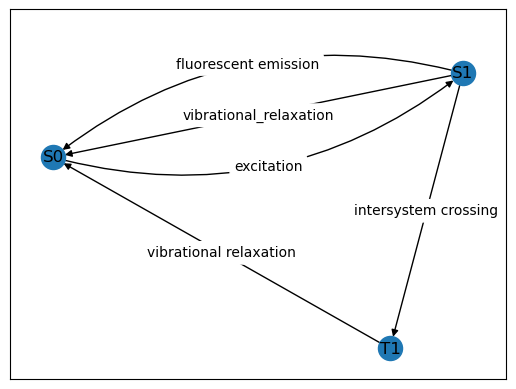

In [39]:
fi.FigureCollection(system).network(100)

### Simulate the Markov process

In [5]:
system.simulate(n_steps=10000000, seed=99)

In [6]:
system.process()

### State occupation histograms and durations

In [12]:
number_single_states = len(system.single_states)
number_transitions = len(system.rates)

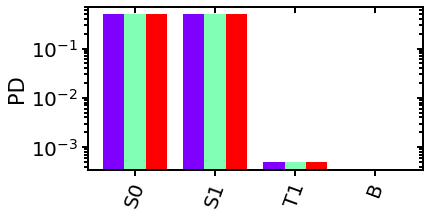

In [15]:
fig, ax = fi.FigureCollection(system).populations(mode="single_states", single_fluorophores=True,
                                                  bins=np.arange(0, number_single_states+1)-0.5)
# shows all possible states of the system, even if not occupied, if bins parameter allows it

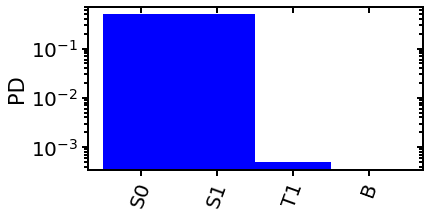

In [16]:
fig, ax = fi.FigureCollection(system).populations(mode="single_states", single_fluorophores=False, 
                                                  bins=np.arange(0, number_single_states+1)-0.5)
# shows all possible states of the system, even if not occupied, if bins parameter allows it

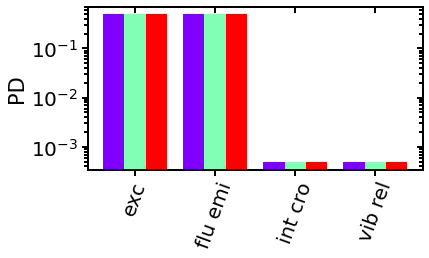

In [17]:
fig, ax = fi.FigureCollection(system).populations(mode="transitions", single_fluorophores=True,
                                                  bins=np.arange(0, number_transitions+1)-0.5)
# shows all possible transitions of the system, even if they didn't happen, if bins parameter 
# allows it

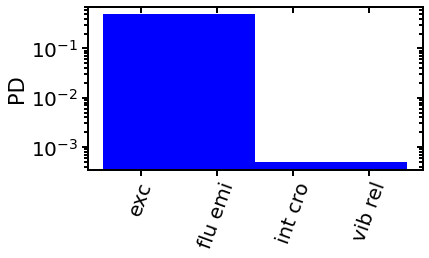

In [18]:
fig, ax = fi.FigureCollection(system).populations(mode="transitions", single_fluorophores=False,
                                                  bins=np.arange(0, number_transitions+1)-0.5)
# shows all possible transitions of the system, even if they didn't happen, if bins parameter
# allows it

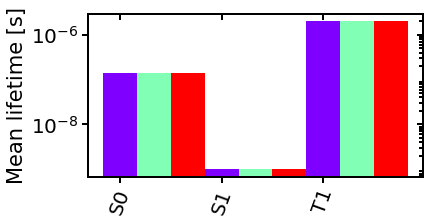

In [10]:
fig, ax = fi.FigureCollection(system).lifetimes(mode="single_states", statistic="mean",
                                                single_fluorophores=True)
# cuts out states that have no lifetime (absorbing or unoccupied states) from right to left

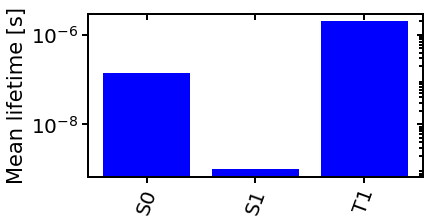

In [11]:
fig, ax = fi.FigureCollection(system).lifetimes(mode="single_states", statistic="mean",
                                                single_fluorophores=False)
# cuts out states that have no lifetime (absorbing or unoccupied states) from right to left

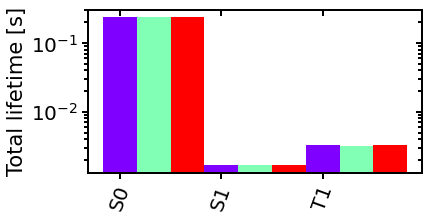

In [12]:
fig, ax = fi.FigureCollection(system).lifetimes(mode="single_states", statistic="total",
                                                single_fluorophores=True)
# cuts out states that have no lifetime (absorbing or unoccupied states) from right to left

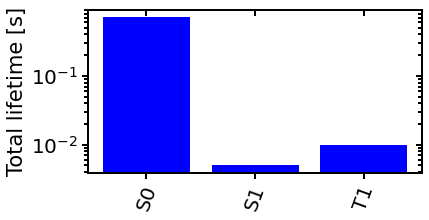

In [13]:
fig, ax = fi.FigureCollection(system).lifetimes(mode="single_states", statistic="total",
                                                single_fluorophores=False)
# cuts out states that have no lifetime (absorbing or unoccupied states) from right to left

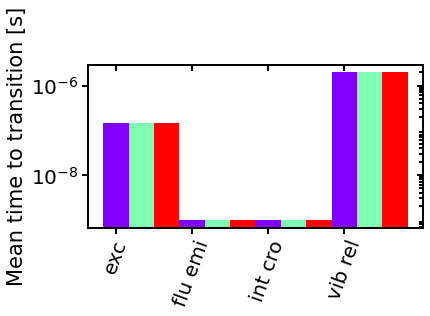

In [14]:
fig, ax = fi.FigureCollection(system).lifetimes(mode="transitions",
                                                single_fluorophores=True)
# cuts out transitions that didn't occur from right to left

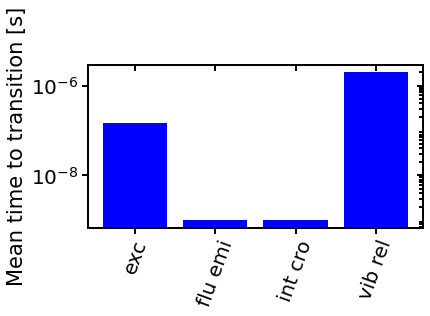

In [15]:
fig, ax = fi.FigureCollection(system).lifetimes(mode="transitions",
                                                single_fluorophores=False)
# cuts out transitions that didn't occur from right to left

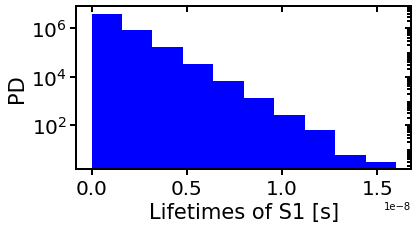

In [16]:
fig, ax = fi.FigureCollection(system).individual_lifetimes(fluorophore_id=0, 
                                                           single_state_id=1)

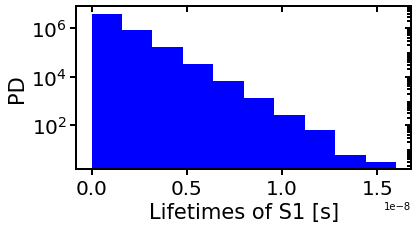

In [17]:
fig, ax = fi.FigureCollection(system).individual_lifetimes(fluorophore_id=None,
                                                           single_state_id=1)

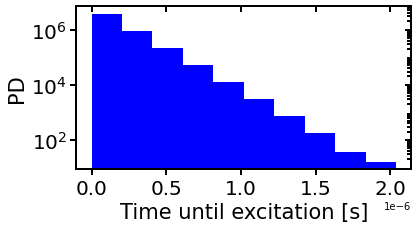

In [18]:
fig, ax = fi.FigureCollection(system).individual_lifetimes(fluorophore_id=None,
                                                           transition_id=0)

### Emission analysis
Depends largely on the resample parameter in method 'emitters', which resembles the time interval of one frame recorded by the camera (hence, it depends on the frame rate of the camera). The central unit is seconds (index of pandas_series - no matter the resample parameter; deltat of fcs also in seconds (the x-axis can still be *displayed* in other units)) and the accuracy is nanoseconds.

In [59]:
system.emitters(photon_collection=1, resample="1 us", emccd_gain=100,
                threshold=0, memory=0, use_unique=True, remove_heading_off_period=False, 
                seed=100)

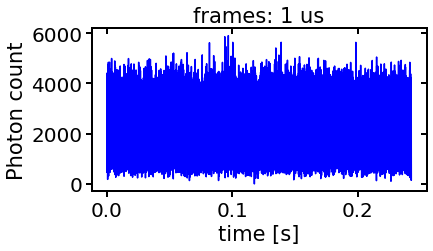

In [62]:
fig, ax = fi.FigureCollection(system).emission_events(time_series=True)

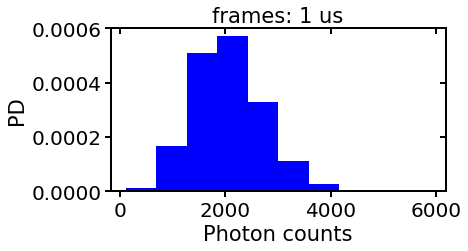

In [63]:
fig, ax = fi.FigureCollection(system).emission_events(time_series=False,
                                                      pois=False)

#### Fluorescence correlation spectroscopy

In [71]:
system.fcs(normalize=True, log=True, m=2, deltat=2e-6)

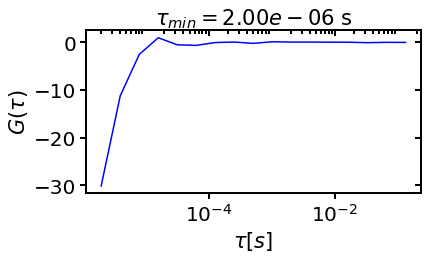

In [88]:
fig, ax = fi.FigureCollection(system).fcs(log=True, normalize_to=4, unit="s")

#### ON periods and OFF periods
An ON period is a number of consecutive frames where each frame contains a minimum amount of emissions ($>$ threshold). 
An OFF period is a number of consecutive frames where each frame contains a maximum amount of emissions ($\le$ threshold).

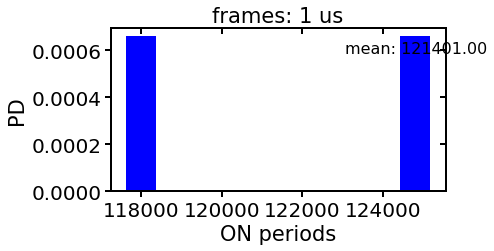

In [64]:
fig, ax = fi.FigureCollection(system).on_off(mode="on", time_series=False, display_mean=True)

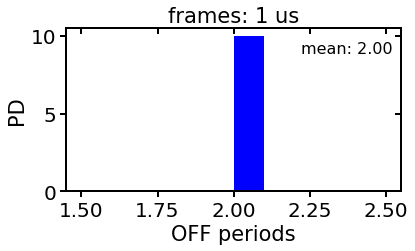

In [65]:
fig, ax = fi.FigureCollection(system).on_off(mode="off", time_series=False, display_mean=True)

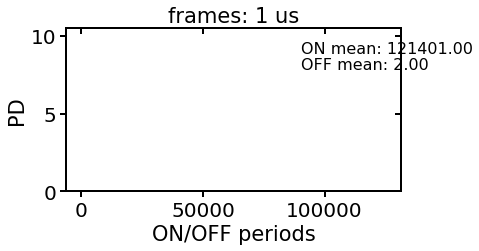

In [66]:
fig, ax = fi.FigureCollection(system).on_off(mode="mesh", time_series=False, display_mean=True)

#### Time series of ON and OFF periods
Displays all ON (or OFF) periods consecutively with their number of frames. Note that each ON period is followed by an OFF period and vice versa.

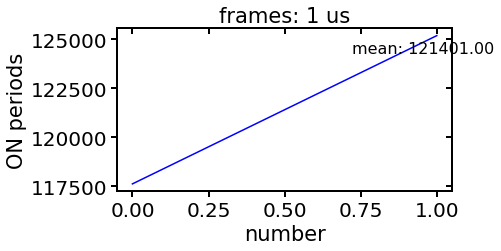

In [67]:
fig, ax = fi.FigureCollection(system).on_off(mode="on", time_series=True, display_mean=True)

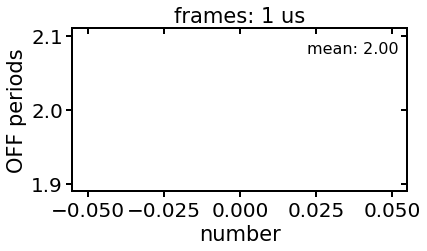

In [68]:
fig, ax = fi.FigureCollection(system).on_off(mode="off", time_series=True, display_mean=True)

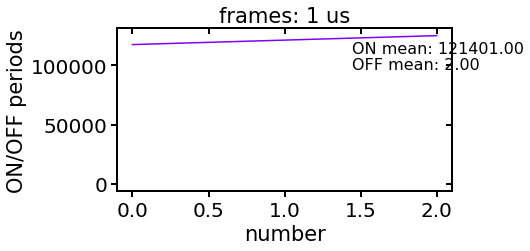

In [69]:
fig, ax = fi.FigureCollection(system).on_off(mode="mesh", time_series=True)

### Visualization

In [19]:
system.animate(index_min=0, index_range=15, fps=2, saveas="animations\classic_jablonski.mp4")

In [20]:
HTML("""
<div align="middle">
<video width="80%" controls>
      <source src="animations\classic_jablonski.mp4" type="video/mp4">
</video></div>""")